In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# From this dataset, I'm going to predict which category the customer product lies in , by using DecisionTreeClassifier 


# Input: customername,productname,segment -(if consumer,homeoffice,corporate)
# output: To predict category

In [3]:
df=pd.read_csv("Documents/data science practice/Sree's_DS_practice/Sales_data (1).csv")
df


,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,US-2023-126221,12/30/2022,1/5/2023,Chuck Clark,Eureka,Eureka The Boss Plus 12-Amp Hard Box Upright V...,Home Office,Office Supplies,Appliances,Central,47201,Columbus,Indiana,United States,0.0,56.5110,2,209.300,0.2700
9990,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,"Bush Westfield Collection Bookcases, Fully Ass...",Consumer,Furniture,Bookcases,East,10009,New York City,New York,United States,0.2,12.1176,4,323.136,0.0375
9991,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Wilson Jones,Wilson Jones Legal Size Ring Binders,Consumer,Office Supplies,Binders,East,10009,New York City,New York,United States,0.2,19.7910,3,52.776,0.3750
9992,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,Gear Head AU3700S Headset,Consumer,Technology,Phones,East,10009,New York City,New York,United States,0.0,2.7279,7,90.930,0.0300


In [4]:
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [5]:
df.tail()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
9989,US-2023-126221,12/30/2022,1/5/2023,Chuck Clark,Eureka,Eureka The Boss Plus 12-Amp Hard Box Upright V...,Home Office,Office Supplies,Appliances,Central,47201,Columbus,Indiana,United States,0.0,56.5110,2,209.300,0.2700
9990,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,"Bush Westfield Collection Bookcases, Fully Ass...",Consumer,Furniture,Bookcases,East,10009,New York City,New York,United States,0.2,12.1176,4,323.136,0.0375
9991,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Wilson Jones,Wilson Jones Legal Size Ring Binders,Consumer,Office Supplies,Binders,East,10009,New York City,New York,United States,0.2,19.7910,3,52.776,0.3750
9992,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,Gear Head AU3700S Headset,Consumer,Technology,Phones,East,10009,New York City,New York,United States,0.0,2.7279,7,90.930,0.0300
9993,US-2023-156720,12/30/2022,1/3/2023,Jill Matthias,Other,Bagged Rubber Bands,Consumer,Office Supplies,Fasteners,West,80538,Loveland,Colorado,United States,0.2,-0.6048,3,3.024,-0.2000


In [6]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
zip              0
city             0
state            0
country          0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_m

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [9]:
# Input: customername,productname,segment -(if consumer,homeoffice,corporate)



# one label encoder is not enough,for many columns use multiple labelencoder 

le_cust=LabelEncoder()
le_prod=LabelEncoder()
le_seg=LabelEncoder()
le_cat=LabelEncoder()


df['customer']=le_cust.fit_transform(df['customer'])
df['product']=le_prod.fit_transform(df['product_name'])
df['segment']=le_seg.fit_transform(df['segment'])
df['category']=le_cat.fit_transform(df['category'])

model=DecisionTreeClassifier()

x=df[['customer','product', 'segment']]
y=df['category']



model.fit(x,y)


 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred=model.predict(x)


# Let get inputs from user
print("Sample Customer Names:")
for i, customer in enumerate(le_cust.classes_[:20], start=1):
    print(i, customer)
customer=input("Enter Customer Name")
print("Sample Product Names:")
for i, prod in enumerate(le_prod.classes_[:20], start=1):
    print(i,prod)
product=input("Enter Product Name")
seg=input("Enter Segment Name (Consumer| Home Office | Corporate)")

# consider given inputs also as columns in the dataset
cust=le_cust.transform([customer])[0]
prod=le_prod.transform([product])[0]
if product not in le_prod.classes_[:20]:
    print("Enter Valid Product Name, Product not found ")
segment=le_seg.transform([seg])[0]

# Predict category
prediction=model.predict([[cust,prod,segment]])
category=le_cat.inverse_transform(prediction)
print("Customer comes under Category: ",category[0])



Sample Customer Names:
1 Aaron Bergman
2 Aaron Hawkins
3 Aaron Smayling
4 Adam Bellavance
5 Adam Hart
6 Adam Shillingsburg
7 Adrian Barton
8 Adrian Hane
9 Adrian Shami
10 Aimee Bixby
11 Alan Barnes
12 Alan Dominguez
13 Alan Haines
14 Alan Hwang
15 Alan Schoenberger
16 Alan Shonely
17 Alejandro Ballentine
18 Alejandro Grove
19 Alejandro Savely
20 Aleksandra Gannaway


Enter Customer Name Aaron Hawkins


Sample Product Names:
1 "While you Were Out" Message Book, One Form per Page
2 #10 Gummed Flap White Envelopes, 100/Box
3 #10 Self-Seal White Envelopes
4 #10 White Business Envelopes,4 1/8 x 9 1/2
5 #10- 4 1/8" x 9 1/2" Recycled Envelopes
6 #10- 4 1/8" x 9 1/2" Security-Tint Envelopes
7 #10-4 1/8" x 9 1/2" Premium Diagonal Seam Envelopes
8 #6 3/4 Gummed Flap White Envelopes
9 1.7 Cubic Foot Compact "Cube" Office Refrigerators
10 1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2" X 11" Cards, 25 Env./Pack
11 12 Colored Short Pencils
12 12-1/2 Diameter Round Wall Clock
13 14-7/8 x 11 Blue Bar Computer Printout Paper
14 2300 Heavy-Duty Transfer File Systems by Perma
15 24 Capacity Maxi Data Binder Racks, Pearl
16 24-Hour Round Wall Clock
17 3-ring staple pack
18 3.6 Cubic Foot Counter Height Office Refrigerator
19 36X48 HARDFLOOR CHAIRMAT
20 3D Systems Cube Printer, 2nd Generation, Magenta


Enter Product Name 1.7 Cubic Foot Compact "Cube" Office Refrigerators
Enter Segment Name (Consumer| Home Office | Corporate) Home Office


Customer comes under Category:  Office Supplies


C:\Users\ELCOT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [11]:
# Mini project using Decision tree classifier is completed successfully  

Confusion Matrix:
[[2117    3    1]
 [   6 6011    9]
 [   2    9 1836]]


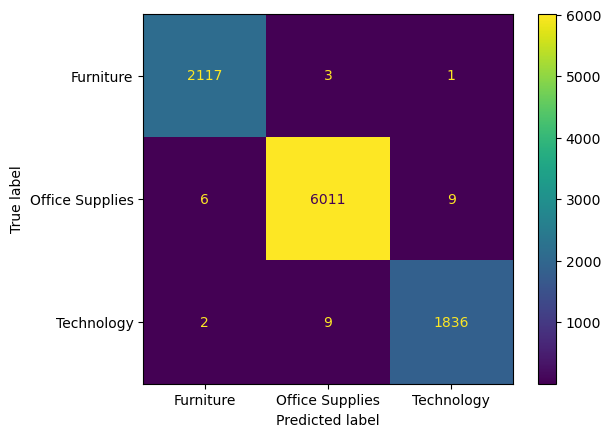

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(x)

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_cat.classes_
)

disp.plot()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy*100)


Accuracy: 99.69981989193516


In [ ]:
# Model is accurate

# Diagonal Values = Correct Predictions => Total correct:2117 + 6011 + 1836= 9964

# only few mistake in the datset which is <30


# Overall, model is trained well and its accuracy score is 99.7%